In [ ]:
!pip install youtube-transcript-api langchain  pydantic

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 9.2 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ------------- -------------------------- 1/3 [jiter]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   ---

In [9]:
from youtube_transcript_api import YouTubeTranscriptApi

def get_transcript_from_url(url: str) -> str:
    video_id = url.split("v=")[-1]
    
    ytt_api = YouTubeTranscriptApi()
    transcript = ytt_api.fetch(video_id)
    
    text = " ".join([t.text for t in transcript])
    return text[:250]

# Example
url = "https://www.youtube.com/watch?v=z_BX6blB_iU"
transcript_text = get_transcript_from_url(url)

print(len(transcript_text))

250


In [10]:
from pydantic import BaseModel, Field
from typing import List

class KeyPointsSchema(BaseModel):
    key_points: List[str] = Field(
        description="5-6 short key points extracted from the video"
    )

In [14]:

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
load_dotenv()
# LLM
# ---- YOUR MODEL (converted to LangChain wrapper) ----
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)


# Parser
parser = PydanticOutputParser(pydantic_object=KeyPointsSchema)

# Prompt
prompt = ChatPromptTemplate.from_template("""
You are an expert content summarizer.

Extract 5-6 important key points from the given YouTube transcript.

Rules:
- Keep each point short (1 line)
- Focus on main ideas only
- Avoid repetition

Transcript:
{transcript}

{format_instructions}
""")

chain = prompt | llm | parser

In [15]:
def extract_key_points(transcript: str):
    result = chain.invoke({
        "transcript": transcript,
        "format_instructions": parser.get_format_instructions()
    })
    return result.key_points

# Test
key_points = extract_key_points(transcript_text)

print(key_points)

['Monkey can scroll for 3 hours without blinking.', 'Monkey can watch five productivity videos in a row without being productive.', 'Monkey can watch unrelated content and call it research.', "Monkey's behavior changes when opening a text.", "Monkey's actions are unproductive despite watching productivity content.", 'Monkey can get distracted by random videos, such as a man restoring a toaster.']


In [16]:
from typing import TypedDict

class BlogState(TypedDict):
    youtube_url: str
    transcript: str
    key_points: list
    blog: str

In [17]:
def transcript_node(state: BlogState):
    transcript = get_transcript_from_url(state["youtube_url"])
    state["transcript"] = transcript
    return state

In [18]:
def keypoints_node(state: BlogState):
    key_points = extract_key_points(state["transcript"])
    state["key_points"] = key_points
    return state

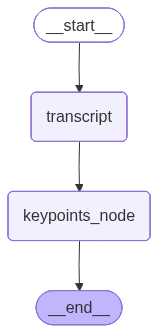

In [19]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(BlogState)

graph.add_node("transcript", transcript_node)
graph.add_node("keypoints_node", keypoints_node)

graph.add_edge(START, "transcript")
graph.add_edge("transcript" , "keypoints_node")
graph.add_edge("keypoints_node" , END)

app = graph.compile()
app

In [21]:
result = app.invoke({
    "youtube_url": "https://www.youtube.com/watch?v=z_BX6blB_iU"
})

In [22]:
result

{'youtube_url': 'https://www.youtube.com/watch?v=z_BX6blB_iU',
 'transcript': 'Monkey can scroll for 3 hours without blinking. Monkey can watch five productivity videos in a row without being productive. Monkey can somehow end up watching a man restore a toaster from 1963 and call it research. But the second monkey opens a text',
 'key_points': ['Monkey can scroll for 3 hours without blinking.',
  'Monkey can watch multiple productivity videos without being productive.',
  'Monkey can get distracted by unrelated content, such as a toaster restoration video.',
  'Monkey claims to be doing research while watching unrelated videos.',
  "Monkey's behavior is an analogy for human procrastination.",
  "Monkey's actions illustrate the potential for mindless scrolling on devices."]}